# Train the Dual-Head U-Net on Synthetic Fields

This notebook is the main workflow. It creates polygon-like agricultural fields, trains the model, evaluates region and boundary metrics, and shows predictions.

In [9]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
PROJECT_ROOT

PosixPath('/Users/ariannoruzi/Desktop/project_hlcv/HLCV_final_project')

In [10]:
from copy import deepcopy
import matplotlib.pyplot as plt

from cfgs import field_segmentation
from src.utils.utils import seed_everything
from src.utils.visualization import show_batch, show_predictions

seed_everything(0)
config = deepcopy(field_segmentation.ftw_dual_head)

## Load Data

The synthetic dataset gives us RGB images, binary masks, instance IDs, and signed-distance-field targets. Replace `synthetic_debug` with `ftw_dual_head` once the real dataset is placed under `data/ftw`.

In [12]:
dm = config['datamodule'](**config['data_args'])
train_loader = dm.get_loader()
valid_loader = dm.get_heldout_loader()

batch = next(iter(train_loader))
show_batch(batch, max_items=3);

TypeError: DataLoader.__init__() got an unexpected keyword argument 'split'

## Train

The debug config only trains for two epochs so the notebook stays lightweight. Increase `config['trainer_config']['epochs']` or switch to `synthetic_full` for a stronger run.

In [4]:
trainer = config['trainer_module'](
    config=config,
    log_dir=PROJECT_ROOT / 'Logs',
    train_loader=train_loader,
    eval_loader=valid_loader,
)
history = trainer.train()
history

epoch: 1 | loss: 1.1489 | bce: 0.5079 | dice_loss: 0.5843 | distance_loss: 0.1528 | polygon_loss: 0.1054 | miou: 0.5380 | dice: 0.6842 | boundary_iou: 0.0592 | instance_f1: 0.0278 | pq: 0.0179 | eval_loss: 1.4237 | eval_bce: 0.6674 | eval_dice_loss: 0.7084 | eval_distance_loss: 0.1367 | eval_polygon_loss: 0.0027 | eval_miou: 0.3672 | eval_dice: 0.5147 | eval_boundary_iou: 0.1397 | eval_instance_f1: 0.3090 | eval_pq: 0.2327


epoch: 2 | loss: 0.9065 | bce: 0.3661 | dice_loss: 0.4868 | distance_loss: 0.1486 | polygon_loss: 0.0532 | miou: 0.8046 | dice: 0.8910 | boundary_iou: 0.2474 | instance_f1: 0.1636 | pq: 0.1251 | eval_loss: 1.3104 | eval_bce: 0.5545 | eval_dice_loss: 0.7064 | eval_distance_loss: 0.1407 | eval_polygon_loss: 0.0070 | eval_miou: 0.0027 | eval_dice: 0.0052 | eval_boundary_iou: 0.0000 | eval_instance_f1: 0.0000 | eval_pq: 0.0000


[{'epoch': 1,
  'loss': 1.148857319355011,
  'bce': 0.5079115986824035,
  'dice_loss': 0.5842930257320404,
  'distance_loss': 0.1528337001800537,
  'polygon_loss': 0.1053637720644474,
  'miou': 0.5380182415246964,
  'dice': 0.6842213839292526,
  'boundary_iou': 0.05922403521835804,
  'instance_f1': 0.02780255520447264,
  'pq': 0.017922823768025536,
  'eval_loss': 1.4237453540166218,
  'eval_bce': 0.6674143671989441,
  'eval_dice_loss': 0.7083915869394938,
  'eval_distance_loss': 0.13674124578634897,
  'eval_polygon_loss': 0.002664040153225263,
  'eval_miou': 0.36715250213940936,
  'eval_dice': 0.5147387385368347,
  'eval_boundary_iou': 0.139680544535319,
  'eval_instance_f1': 0.3089601771309088,
  'eval_pq': 0.2326534473184673},
 {'epoch': 2,
  'loss': 0.9065017461776733,
  'bce': 0.36612020432949066,
  'dice_loss': 0.48675771355628966,
  'distance_loss': 0.1486497402191162,
  'polygon_loss': 0.053213993459939955,
  'miou': 0.8046006679534912,
  'dice': 0.8909828066825867,
  'boundary_

In [5]:
eval_result = trainer.evaluate(valid_loader)
eval_result

{'loss': 1.3103591203689575,
 'bce': 0.5544644792874655,
 'dice_loss': 0.7064222494761149,
 'distance_loss': 0.1407470852136612,
 'polygon_loss': 0.007030831029017766,
 'miou': 0.002659363640608111,
 'dice': 0.005242364282215324,
 'boundary_iou': 1.033993594449593e-09,
 'instance_f1': 0.0,
 'pq': 0.0}

## Visualize Predictions

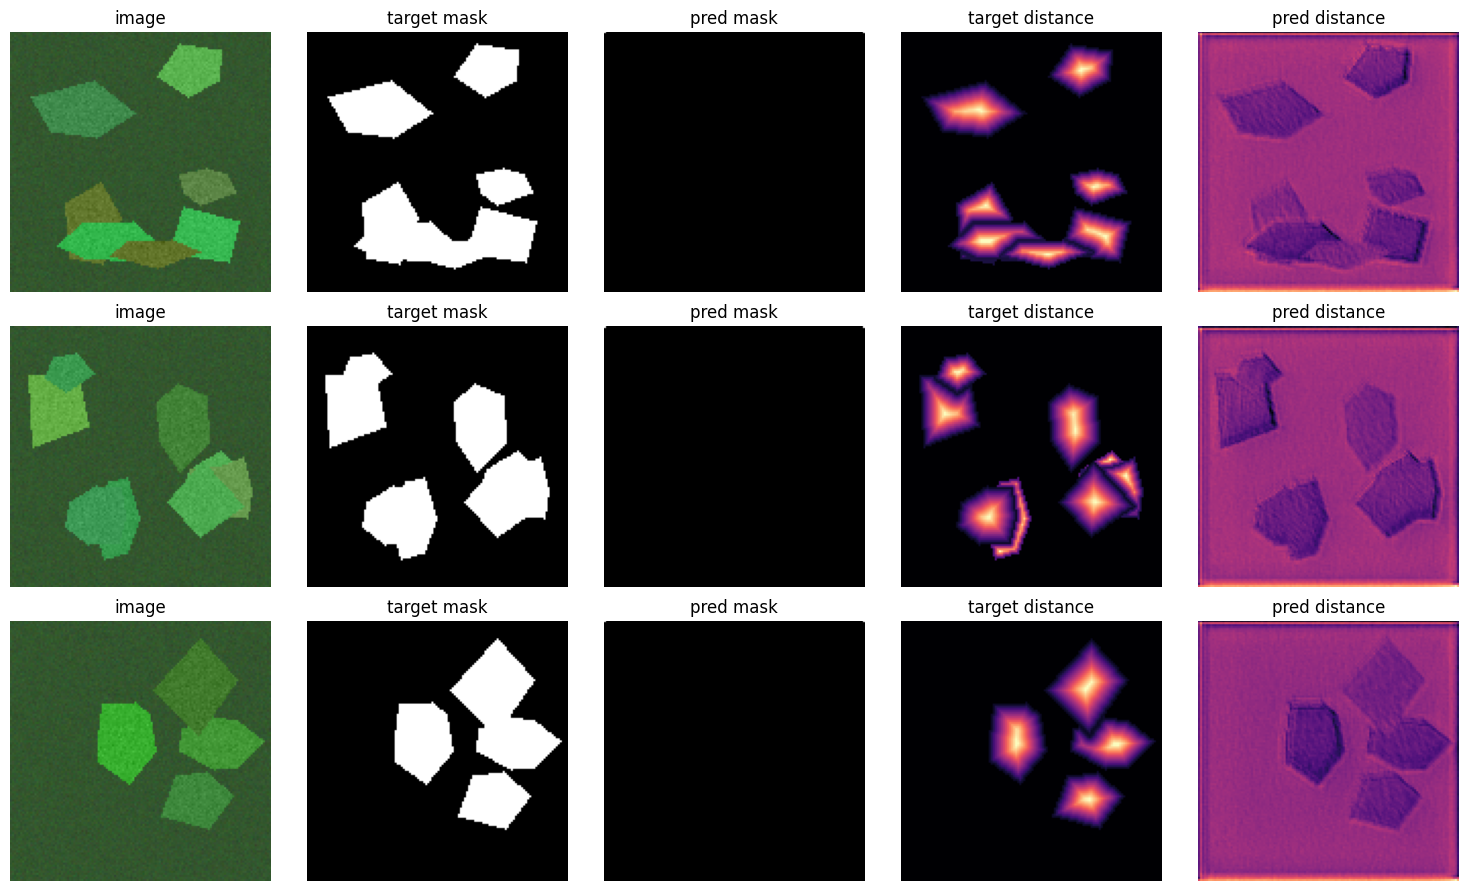

In [6]:
batch = next(iter(valid_loader))
show_predictions(trainer.model, batch, device=trainer.device, max_items=3);

## Checkpoints

Best and last model weights are saved under `Saved/<experiment_name>/best_model.pth` and `Saved/<experiment_name>/last_model.pth`.